In [5]:
import cv2, numpy as np, matplotlib.pyplot as plt, glob
from tqdm import tqdm
from loguru import logger
log = logger.debug
images = sorted(glob.glob("/Volumes/BroadKey0313/DCIM/DJI_20260401*/*.JPG"))

from PIL import Image

In [6]:
# def find_vignette()

In [33]:
def average_random(images, n):
    v = 0
    for i in tqdm(np.random.randint(0, len(images), n)):
        v += np.asarray(Image.open(images[i])).astype(np.float32)
    v /= n
    return v.astype(np.uint8)

def max_random(images, n):
    v = 0
    for i in tqdm(np.random.randint(0, len(images), n)):
        v = np.maximum(v, np.asarray(Image.open(images[i])))
        
    return v

def variance(images, n):
    e = 0
    esq = 0
    for i in tqdm(np.random.randint(0, len(images), n)):
        im = np.asarray(Image.open(images[i])).astype(np.float32)
        e += im
        esq += im * im
        
    variance = np.linalg.norm(e * e - esq, axis=-1)
    return variance

In [42]:
e, esq = variance(images, 200)

100%|████████████████████████████████████████████████████████████████████| 200/200 [00:30<00:00,  6.65it/s]


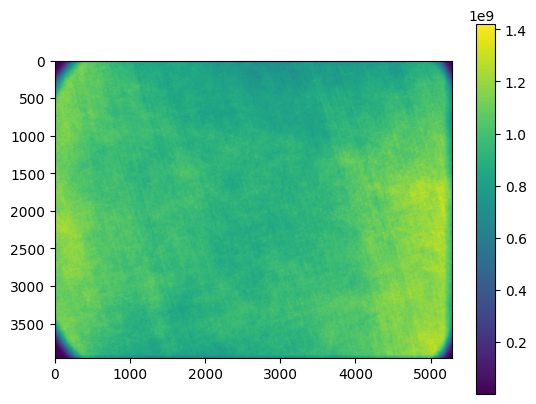

In [44]:
plt.imshow(np.linalg.norm(e * e - esq, axis=-1)); plt.colorbar()

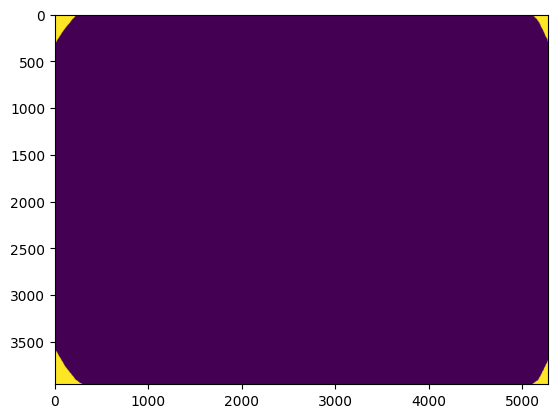

In [48]:
variance = np.linalg.norm(e * e - esq, axis=-1)
plt.imshow(variance < variance.mean() / 2);

In [16]:
avg = average_random(images, 100)

100%|████████████████████████████████████████████████████████████████████| 100/100 [00:12<00:00,  7.87it/s]


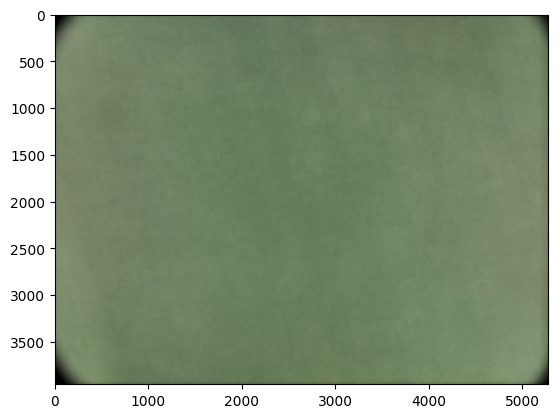

In [17]:
plt.imshow(avg)

In [20]:
max_r = average_random(images, 100)

100%|████████████████████████████████████████████████████████████████████| 300/300 [00:37<00:00,  7.94it/s]


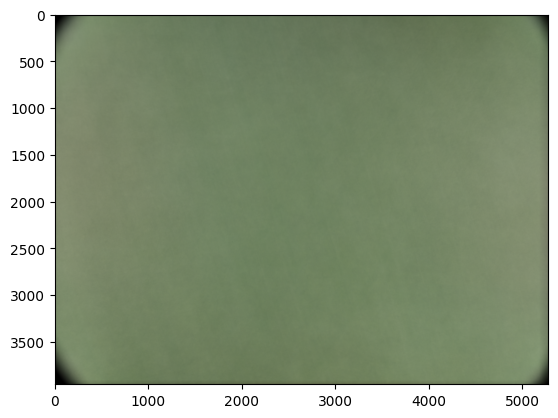

In [21]:
plt.imshow(max_r)

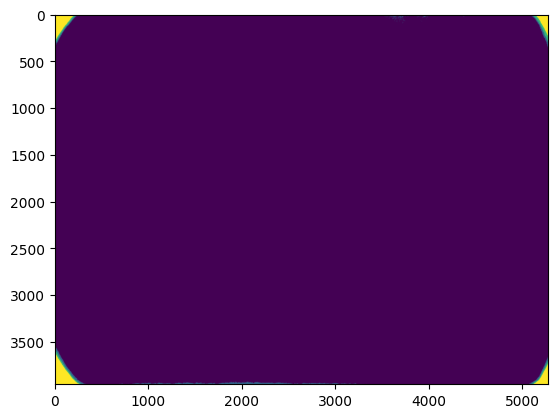

In [32]:
plt.imshow(np.mean(max_r < 80, axis=-1))